# UCB Action Selection vs. Epsilon-Greedy

- This notebook compares a **UCB agent (c = 2.0)** against an **ε-greedy agent (ε = 0.1)** on a stationary 10-armed bandit, both using a constant step size (α = 0.1).

- Unlike ε-greedy's random exploration, UCB selects actions based on an upper confidence bound that favors actions with either high estimated value or high uncertainty (i.e., actions tried less often). This notebook examines how this more targeted exploration strategy compares to ε-greedy in terms of average reward and % optimal action.

In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt


module_path = Path.cwd().parent.resolve()

if str(module_path) not in sys.path:
    sys.path.append(str(module_path))


from bandit_engine import gaussian_arms_factory
from agents import EpsilonGreedyAgent, UCBAgent
from run_experiments import compare_agents
from utils import plot_bandit_performance

In [5]:
RANDOM_SEED = 42
k_arms = 10

agent_configs = [
    {
        "label": "UCB agent - c = 2.0",
        "agent_type": UCBAgent,
        "agent_config": {
            "n_arms": k_arms,
            "initial_value": 0.0,
            "c": 2.0,
            "alpha": 0.1
        }
    },
    {
        "label": "e-greedy agent - eps = 0.1",
        "agent_type": EpsilonGreedyAgent,
        "agent_config": {
            "n_arms": k_arms,
            "epsilon": 0.1,
            "initial_value": 0.0,
            "alpha": 0.1
        }
    }
]

# Set experiment parameters and run comparison
n_runs = 2000
n_steps = 1000
non_stationary = True

results = compare_agents(
    arm_factory=gaussian_arms_factory,
    agent_configs=agent_configs,
    random_seed=RANDOM_SEED,
    n_runs=n_runs,
    n_steps=n_steps,
    non_stationary=non_stationary
)

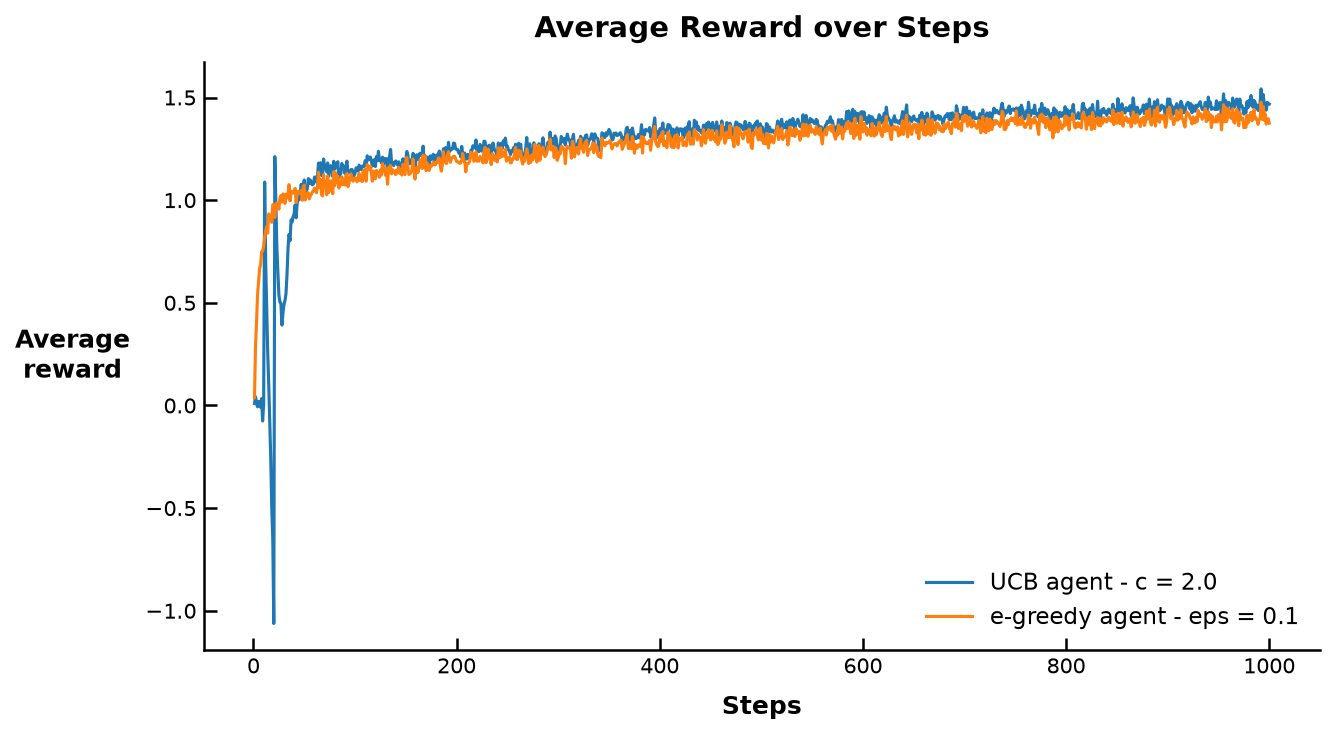

In [ ]:
# Unpack the results tuple into separate dictionaries for each metric
rewards_dict = {label: data[0] for label, data in results.items()}
optimal_actions_dict = {label: data[1] for label, data in results.items()}

# Custom color mapping matching the agent labels used in agent_configs
custom_colors = {
    "UCB": "#1F77B4",
    "e-greedy": "#FF7F0E"
}

fig_reward, ax_reward = plot_bandit_performance(
    metrics_data=rewards_dict,
    metric_type="reward",
    title="Average Reward over Steps",
    colors=custom_colors
)

plt.show()

## Observations:
- The UCB agent shows a sharp dip in average reward early on (down to about −1.0 around step 20). This comes directly from the UCB action-selection rule: the uncertainty bonus `c·√(ln(t)/N(a))` is infinite for any action that hasn't been tried yet, which forces the agent to systematically try every action at least once early in training. If one of those first-time samples happens to yield an unlucky, low reward (due to the Gaussian variance of the bandit), it temporarily drags down the average — this is the dip visible here, which the ε-greedy agent doesn't show since it isn't forced to sample every action so early.
- Once every action has been tried a few times, the UCB agent's exploration becomes more targeted — it preferentially revisits actions that are either promising or highly uncertain — while ε-greedy continues to explore uniformly at random 10% of the time regardless of what it already knows. This more efficient, uncertainty-driven exploration lets UCB recover quickly and maintain a slightly higher average reward than ε-greedy through most of the run, though the two converge to a similar level by step 1000.

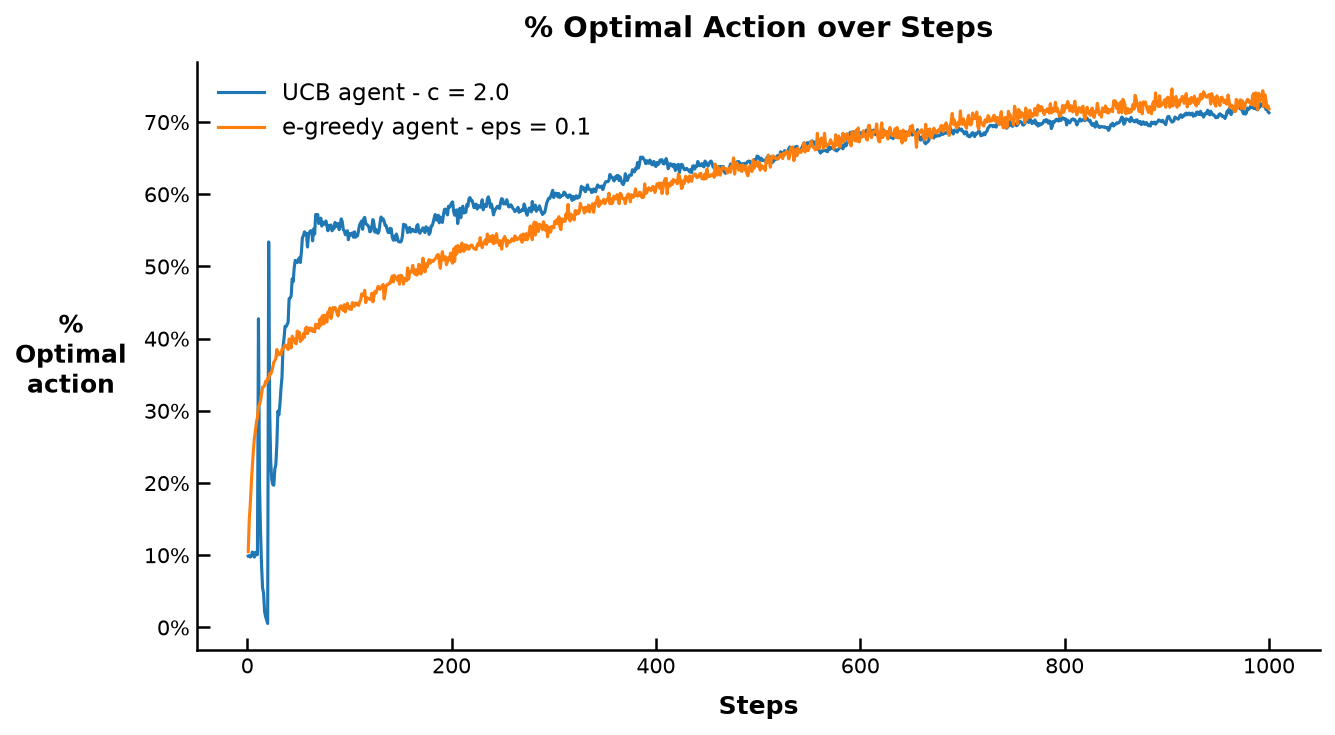

In [7]:
fig_optimal, ax_optimal = plot_bandit_performance(
    metrics_data=optimal_actions_dict,
    metric_type="optimal_action",
    title="% Optimal Action over Steps",
    colors=custom_colors
)
plt.show()

## Observations:
- The %-optimal-action plot makes the forced initial exploration of UCB even clearer: right after the mandatory first pass through all 10 actions, its optimal-action rate briefly collapses toward 0% (around step 20) before recovering, since one of those forced, untried actions was picked purely because of its infinite uncertainty bonus rather than because it looked good.
- After this initial forced-exploration phase, UCB's uncertainty-based exploration becomes more efficient than ε-greedy's random exploration — it stops wasting samples on actions it is already confident about, and instead directs exploration toward actions with high uncertainty or high potential. This lets UCB reach a higher optimal-action rate earlier (~55-60% by step 200, versus ~40% for ε-greedy).
- In the later steps, however, ε-greedy gradually catches up and the two curves converge to a similar ~72-73% optimal-action rate by step 1000. This is expected: with enough steps, both agents accumulate enough samples per action that their value estimates become accurate, and ε-greedy's constant 10% random-exploration cost becomes the main remaining difference between the two — while UCB's uncertainty bonus naturally shrinks over time as N(a) grows for all actions, making its behavior converge toward pure greedy exploitation as well.